In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
# Merge data from corpora
run = 1
model = 'gpt-4o-mini'

datasets = []
for corpus in ['meco', 'provo', 'onestop']:
    df = pd.read_csv(f'../data/output/{model}/{corpus}/{corpus}_words_plus_triplets_gpt-4o-mini_{run}_all.csv')
    df['corpus'] = [corpus for i in range(len(df))]
    datasets.append(df)
df = pd.concat(datasets,ignore_index=True)
df.dropna(subset=['n_triplets'], inplace=True)

/var/folders/fk/f89cd5k937qcllmv7924k0bc0000gn/T/ipykernel_14653/992000242.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),


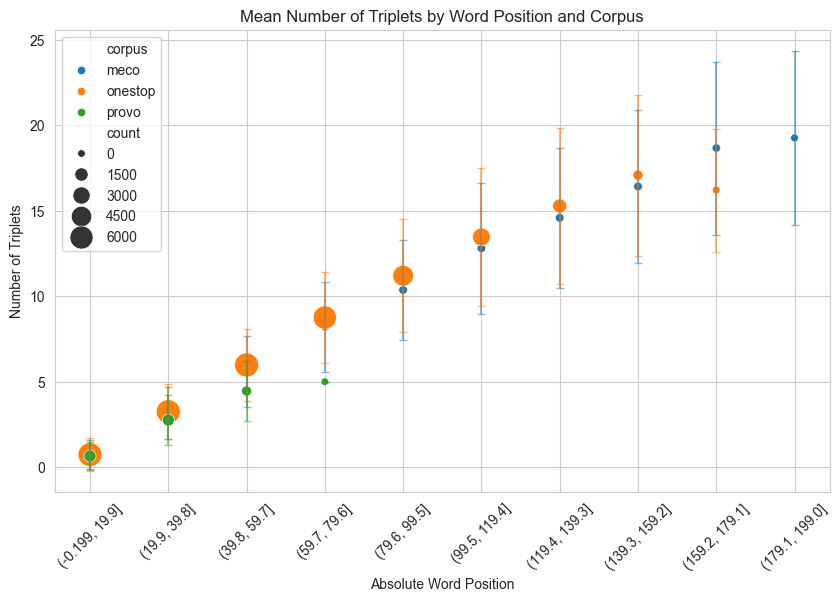

<Figure size 640x480 with 0 Axes>

In [28]:
# Number of triplets per absolute word position in text with size of dots representing data points
# df['ianum_bin'] = df.groupby('corpus')['ianum'].transform(lambda x: pd.cut(x, bins=10))
df['ianum_bin'] = pd.cut(df['ianum'], bins=10)
grouped = df.groupby(['ianum_bin', 'corpus']).agg(mean_triplets=('n_triplets', 'mean'),
                                                  std_triplets=('n_triplets', 'std'),
                                                  count=('ianum', 'count')).reset_index()
grouped['ianum_bin'] = grouped['ianum_bin'].astype(str)
sns.set_style('whitegrid')
palette = sns.color_palette("tab10", n_colors=grouped['corpus'].nunique())
corpus_colors = dict(zip(grouped['corpus'].unique(), palette))
plt.figure(figsize=(10, 6))
graph = sns.scatterplot(data=grouped, x='ianum_bin', y='mean_triplets', size='count', hue='corpus', sizes=(30, 300), palette=corpus_colors)
for i in range(grouped.shape[0]):
    row = grouped.iloc[i]
    plt.errorbar(x=row['ianum_bin'],y=row['mean_triplets'],yerr=row['std_triplets'] if pd.notnull(row['std_triplets']) else 0,
                 fmt='none',ecolor=corpus_colors[row['corpus']],capsize=3, alpha=0.5)
plt.xticks(rotation=45)
plt.title('Mean Number of Triplets by Word Position and Corpus')
plt.xlabel('Absolute Word Position')
plt.ylabel('Number of Triplets')
# plt.tight_layout()
plt.show()

plt.clf()

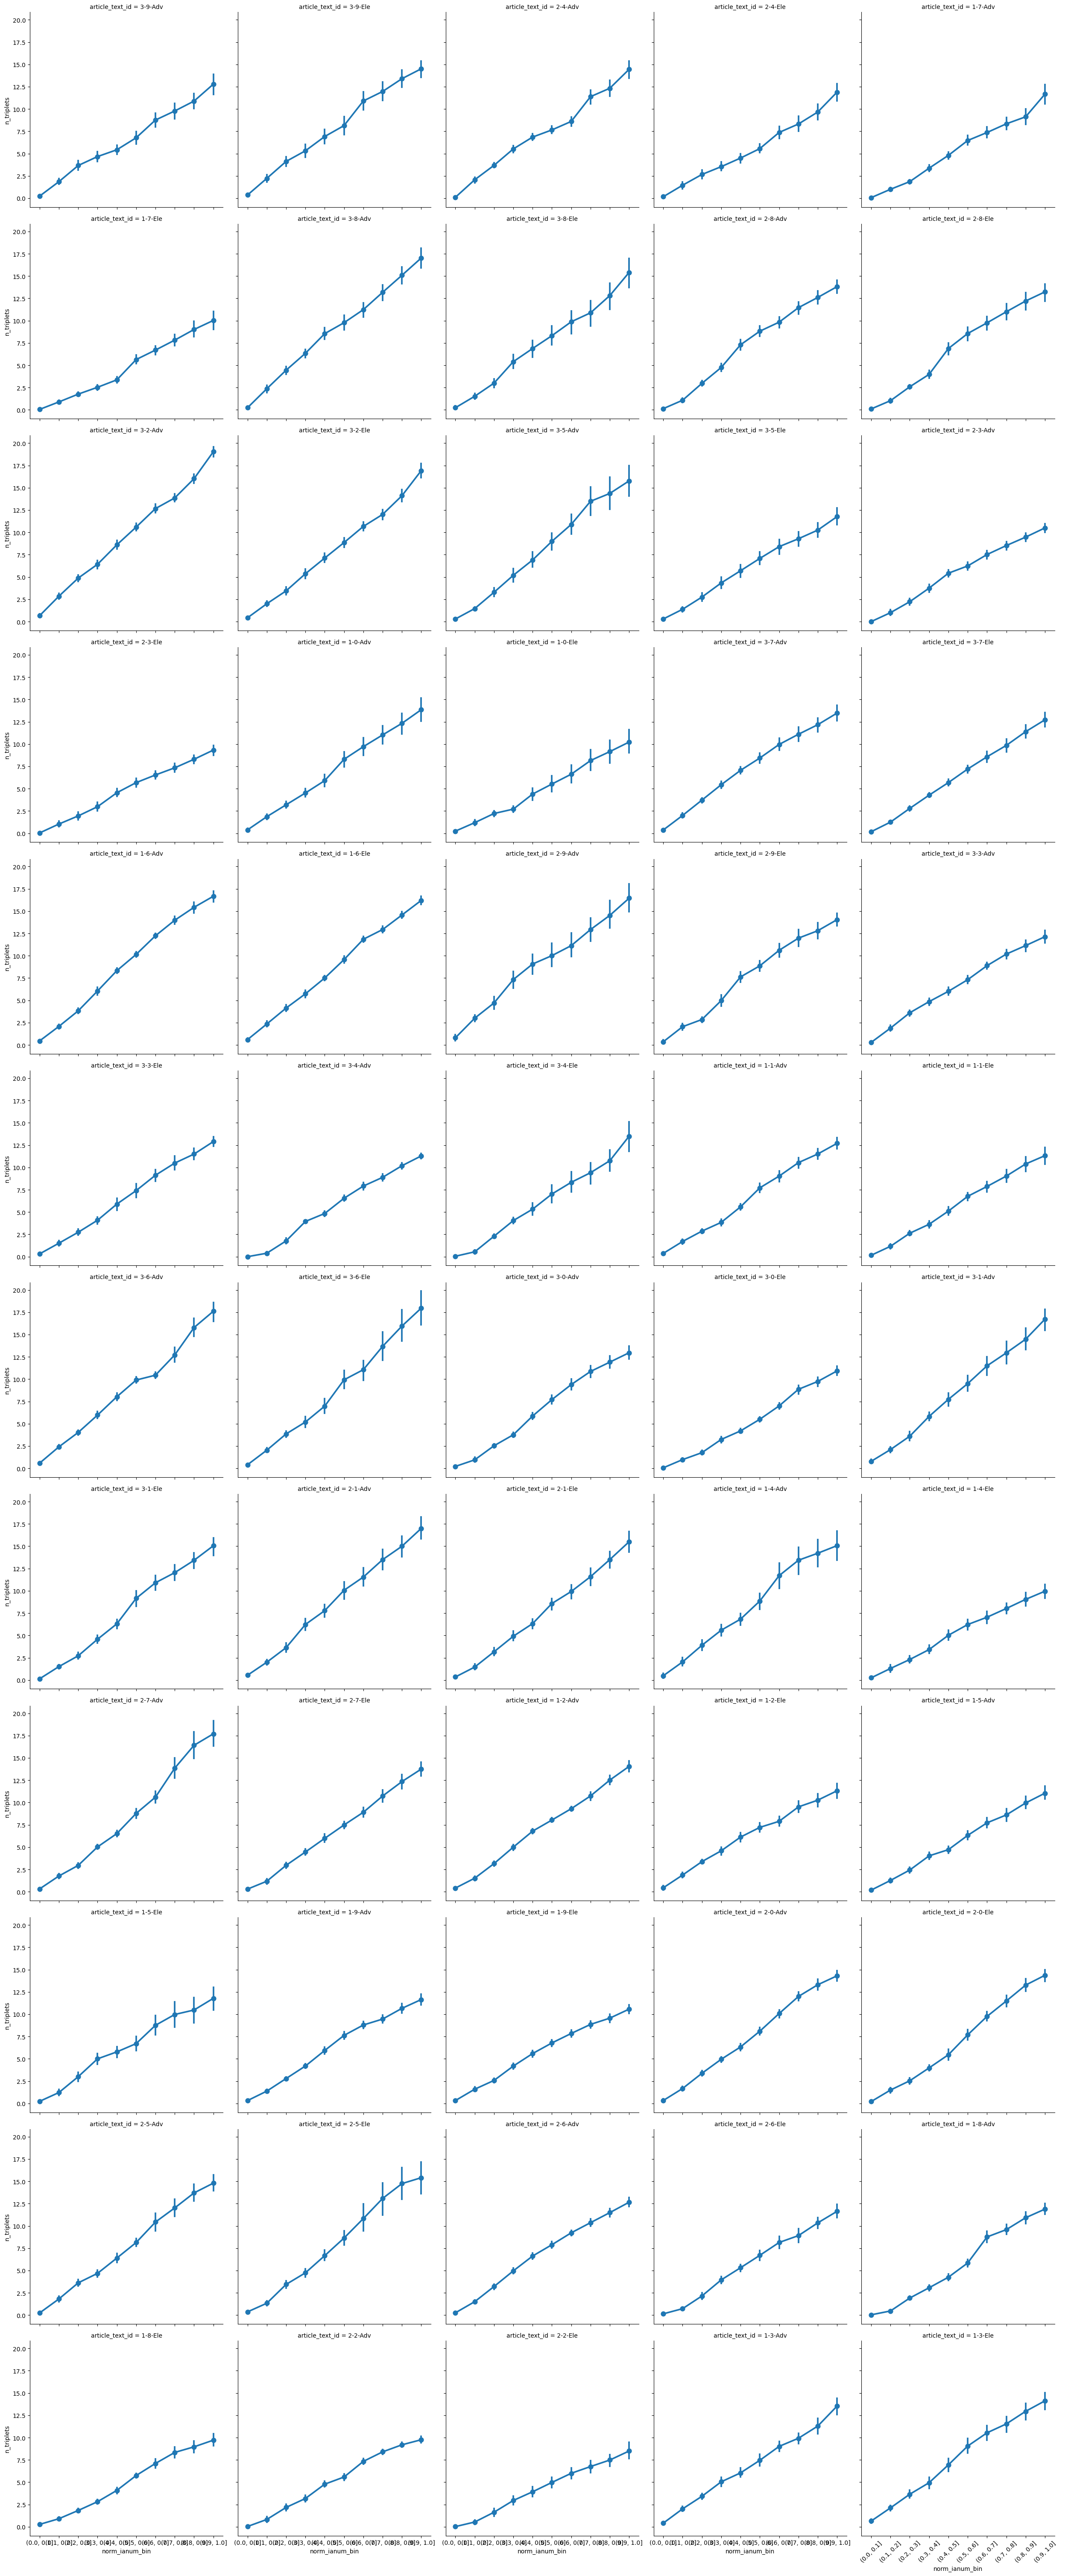

<Figure size 640x480 with 0 Axes>

In [30]:
# Number of triplets per word position per text in a corpus
corpus_name = 'onestop'
model_name = 'gpt-4o-mini'
df_corpus = pd.read_csv(f'../data/output/{model_name}/{corpus_name}/{corpus_name}_words_plus_triplets_gpt-4o-mini_1_all.csv')
df_corpus.dropna(subset=['n_triplets'], inplace=True)
df_corpus['article_text_id'] = [f'{article_batch}-{article_id}-{difficulty_level}'
                             for article_batch, article_id, difficulty_level in
                             zip(df_corpus['article_batch'].tolist(), df_corpus['article_id'].tolist(),
                                 df_corpus['difficulty_level'].tolist())]
df_corpus['norm_ianum_bin'] = pd.cut(df_corpus['norm_ianum'], bins=[0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1.])
graph = sns.catplot(df_corpus, x='norm_ianum_bin', y='n_triplets', col='article_text_id', col_wrap=5, kind="point")
plt.xticks(rotation=45)
# plt.tight_layout()
plt.show()
plt.clf()

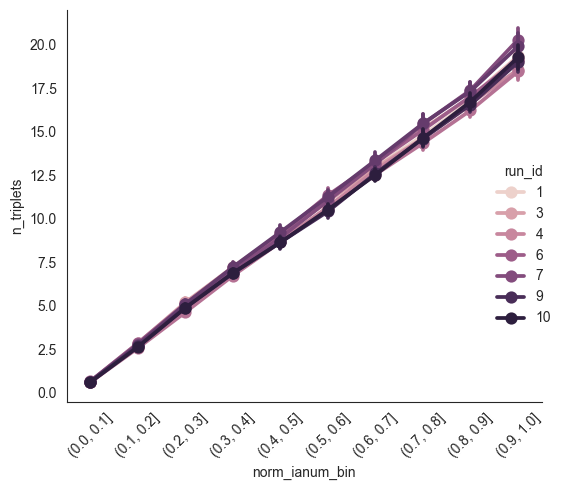

<Figure size 640x480 with 0 Axes>

In [27]:
# Number of triplets per word position in text per run (for one corpus)
corpus_name = 'meco'
model_name = 'gpt-4o-mini'
df_corpus = pd.read_csv(f'../data/output/{model_name}/{corpus_name}/{corpus_name}_words_plus_triplets_gpt-4o-mini_all.csv')
df_corpus.dropna(subset=['n_triplets'], inplace=True)
df_corpus['norm_ianum_bin'] = pd.cut(df_corpus['norm_ianum'], bins=[0,.1,.2,.3,.4,.5,.6,.7,.8,.9,1.])
graph = sns.catplot(df_corpus, x='norm_ianum_bin', y='n_triplets', hue='run_id', kind="point")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
plt.clf()